In [ ]:
## Exploratory Data Analysis of Lightning Strikes Data

In [ ]:
## Import libraries

This section imports the Python libraries used in the analysis.

- **pandas** is used for working with tabular data  
- **numpy** supports numerical operations  
- **seaborn** is used for statistical visualizations  
- **datetime** helps with date and time operations  
- **matplotlib** is used to create charts and customize plots

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
from matplotlib import pyplot as plt

In [ ]:
## Load the dataset

This cell reads the 2018 dataset into a pandas DataFrame called `df`.

A DataFrame is a table-like structure that makes it easier to inspect, clean, and analyze data.  
The `head()` method displays the first five rows so we can quickly confirm that the data loaded correctly.

In [4]:
df = pd.read_csv('eda_structuring_with_python_dataset1.csv') 
df.head()

,date,number_of_strikes,center_point_geom
0,2018-01-03,194,POINT(-75 27)
1,2018-01-03,41,POINT(-78.4 29)
2,2018-01-03,33,POINT(-73.9 27)
3,2018-01-03,38,POINT(-73.8 27)
4,2018-01-03,92,POINT(-79 28)


In [ ]:
## Convert the date column

The `date` column is converted to datetime format so that Python can recognize it as a true date field.

This is important because it allows us to extract useful time-based information later, such as:
- day of the week
- week number
- month
- year

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.shape

(3401012, 3)

In [8]:
df.drop_duplicates().shape

(3401012, 3)

In [9]:
df.sort_values(by='number_of_strikes', ascending=False).head(10)

,date,number_of_strikes,center_point_geom
302758,2018-08-20,2211,POINT(-92.5 35.5)
278383,2018-08-16,2142,POINT(-96.1 36.1)
280830,2018-08-17,2061,POINT(-90.2 36.1)
280453,2018-08-17,2031,POINT(-89.9 35.9)
278382,2018-08-16,1902,POINT(-96.2 36.1)
11517,2018-02-10,1899,POINT(-95.5 28.1)
277506,2018-08-16,1878,POINT(-89.7 31.5)
24906,2018-02-25,1833,POINT(-98.7 28.9)
284320,2018-08-17,1767,POINT(-90.1 36)
24825,2018-02-25,1741,POINT(-98 29)


In [10]:
df.center_point_geom.value_counts()

center_point_geom
POINT(-81.5 22.5)    108
POINT(-84.1 22.4)    108
POINT(-82.5 22.9)    107
POINT(-82.7 22.9)    107
POINT(-82.5 22.8)    106
                    ... 
POINT(-54.8 44.1)      1
POINT(-51.2 44.4)      1
POINT(-51.2 44.5)      1
POINT(-60.9 45.2)      1
POINT(-58.5 45.3)      1
Name: count, Length: 170855, dtype: int64

In [ ]:
## Sort by number of strikes

This code sorts the dataset by `number_of_strikes` in descending order and shows the top 10 rows.

It helps identify the records with the highest lightning activity in the dataset.

In [11]:
df.center_point_geom.value_counts()[:20].rename_axis('unique_values').reset_index(name='counts').style.background_gradient()

,unique_values,counts
0,POINT(-81.5 22.5),108
1,POINT(-84.1 22.4),108
2,POINT(-82.5 22.9),107
3,POINT(-82.7 22.9),107
4,POINT(-82.5 22.8),106
5,POINT(-84.2 22.3),106
6,POINT(-75.9 20.4),105
7,POINT(-76 20.5),105
8,POINT(-78 18.2),104
9,POINT(-82.2 22.9),104


In [ ]:
## Create new time-based columns

This section creates two additional columns from the `date` field:

- `week` stores the ISO week number  
- `weekday` stores the name of the day

These new columns make it easier to analyze lightning activity by time patterns.

In [12]:
df['week'] = df.date.dt.isocalendar().week
df['weekday'] = df.date.dt.day_name()
df.head()

,date,number_of_strikes,center_point_geom,week,weekday
0,2018-01-03,194,POINT(-75 27),1,Wednesday
1,2018-01-03,41,POINT(-78.4 29),1,Wednesday
2,2018-01-03,33,POINT(-73.9 27),1,Wednesday
3,2018-01-03,38,POINT(-73.8 27),1,Wednesday
4,2018-01-03,92,POINT(-79 28),1,Wednesday


In [ ]:
## Calculate average strikes by weekday

This step groups the data by weekday and calculates the mean number of strikes for each day.

It helps show whether some days of the week tend to have higher average lightning activity than others.

In [13]:
df[['weekday', 'number_of_strikes',]].groupby(['weekday']).mean()

,number_of_strikes
weekday,
Friday,13.349972
Monday,13.152804
Saturday,12.732694
Sunday,12.324717
Thursday,13.240594
Tuesday,13.813599
Wednesday,13.224568


In [ ]:
## Set weekday order

This list defines the correct calendar order of weekdays.

It is used in the visualization step so the days appear from Monday to Sunday instead of in alphabetical order.

In [ ]:
## Visualize strike distribution by weekday

This boxplot shows how lightning strike counts are distributed across different days of the week.

- the x-axis represents the weekday  
- the y-axis shows the number of strikes  
- `showfliers=False` hides extreme outliers for a cleaner view

This chart helps compare the spread and typical range of strike counts for each weekday.

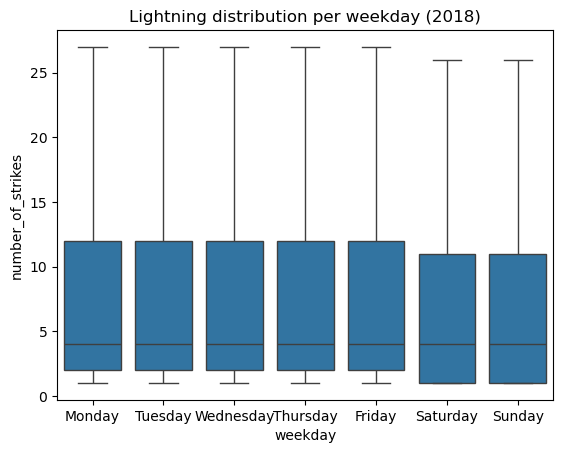

In [14]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
g = sns.boxplot(data=df,
               x='weekday',
               y='number_of_strikes',
               order=weekday_order,
               showfliers=False
               );
g.set_title('Lightning distribution per weekday (2018)');

In [ ]:
## Load the second dataset

This cell imports another dataset containing data from 2016–2017 into a new DataFrame called `df_2`.

The `head()` method is used again to preview the data and confirm that it loaded properly.

In [15]:
df_2 = pd.read_csv('eda_structuring_with_python_dataset2.csv')
df_2.head()

,date,number_of_strikes,center_point_geom
0,2016-01-04,55,POINT(-83.2 21.1)
1,2016-01-04,33,POINT(-83.1 21.1)
2,2016-01-05,46,POINT(-77.5 22.1)
3,2016-01-05,28,POINT(-76.8 22.3)
4,2016-01-05,28,POINT(-77 22.1)


In [ ]:
## Convert dates in the second dataset

The `date` column in the second dataset is converted to datetime format.

This ensures both datasets use the same date type before being combined.

In [16]:
df_2['date'] = pd.to_datetime(df_2['date'])

In [ ]:
## Combine datasets

This step merges the 2018 dataset with the 2016–2017 dataset into one DataFrame called `union_df`.

Before combining them, the `weekday` and `week` columns are removed from the first dataset so both DataFrames have the same structure.

`ignore_index=True` resets the row numbering in the final combined DataFrame.

In [17]:
union_df = pd.concat([df.drop(['weekday','week'],axis=1), df_2], ignore_index=True)
union_df.head()

,date,number_of_strikes,center_point_geom
0,2018-01-03,194,POINT(-75 27)
1,2018-01-03,41,POINT(-78.4 29)
2,2018-01-03,33,POINT(-73.9 27)
3,2018-01-03,38,POINT(-73.8 27)
4,2018-01-03,92,POINT(-79 28)


In [ ]:
## Create additional date features

This section adds three new columns based on the `date` field:

- `year` for the year value  
- `month` for the month number  
- `month_txt` for the full month name

These columns make it easier to compare lightning activity over time.

In [18]:
union_df['year'] = union_df.date.dt.year
union_df['month'] = union_df.date.dt.month
union_df['month_txt'] = union_df.date.dt.month_name()
union_df.head()

,date,number_of_strikes,center_point_geom,year,month,month_txt
0,2018-01-03,194,POINT(-75 27),2018,1,January
1,2018-01-03,41,POINT(-78.4 29),2018,1,January
2,2018-01-03,33,POINT(-73.9 27),2018,1,January
3,2018-01-03,38,POINT(-73.8 27),2018,1,January
4,2018-01-03,92,POINT(-79 28),2018,1,January


In [ ]:
## Calculate total strikes per year

This step groups the data by year and sums the number of lightning strikes in each year.

It provides a high-level view of how total lightning activity changed from year to year.

In [19]:
union_df[['year','number_of_strikes']].groupby(['year']).sum()

,number_of_strikes
year,
2016,41582229
2017,35095195
2018,44600989


In [ ]:
## Merge monthly and yearly data

This step combines the monthly strike totals with the yearly totals using the `year` column.

As a result, each row now contains:
- the month
- the year
- the number of strikes in that month
- the total strikes for that year

This makes percentage calculations possible.

In [21]:
lightning_by_month = union_df.groupby(['month_txt','year']).agg(
    number_of_strikes = pd.NamedAgg(column='number_of_strikes',aggfunc=sum)
    ).reset_index()

lightning_by_month.head()

,month_txt,year,number_of_strikes
0,April,2016,2636427
1,April,2017,3819075
2,April,2018,1524339
3,August,2016,7250442
4,August,2017,6021702


In [22]:
lightning_by_year = union_df.groupby(['year']).agg(
    year_strikes = pd.NamedAgg(column='number_of_strikes',aggfunc=sum)
).reset_index()
lightning_by_year.head()

,year,year_strikes
0,2016,41582229
1,2017,35095195
2,2018,44600989


In [23]:
percentage_lightning = lightning_by_month.merge(lightning_by_year,on='year')
percentage_lightning.head()

,month_txt,year,number_of_strikes,year_strikes
0,April,2016,2636427,41582229
1,April,2017,3819075,35095195
2,April,2018,1524339,44600989
3,August,2016,7250442,41582229
4,August,2017,6021702,35095195


In [ ]:
## Calculate monthly percentages

This step creates a new column called `percentage_lightning_per_month`.

It shows what percentage of the total yearly lightning strikes occurred in each month.

The formula used is:

**monthly strikes / yearly strikes × 100**

In [24]:
percentage_lightning['percentage_lightning_per_month'] = (percentage_lightning.number_of_strikes/
                                                          percentage_lightning.year_strikes * 100.0)
percentage_lightning.head()

,month_txt,year,number_of_strikes,year_strikes,percentage_lightning_per_month
0,April,2016,2636427,41582229,6.340273
1,April,2017,3819075,35095195,10.882045
2,April,2018,1524339,44600989,3.417725
3,August,2016,7250442,41582229,17.436396
4,August,2017,6021702,35095195,17.158195


In [ ]:
## Visualize monthly lightning percentages

This bar chart shows the percentage of yearly lightning strikes that occurred in each month, separated by year.

- `month_order` keeps the months in calendar order  
- `hue='year'` creates separate bars for each year  
- axis labels and the title make the chart easier to interpret

This visualization helps compare seasonal lightning patterns across multiple years.

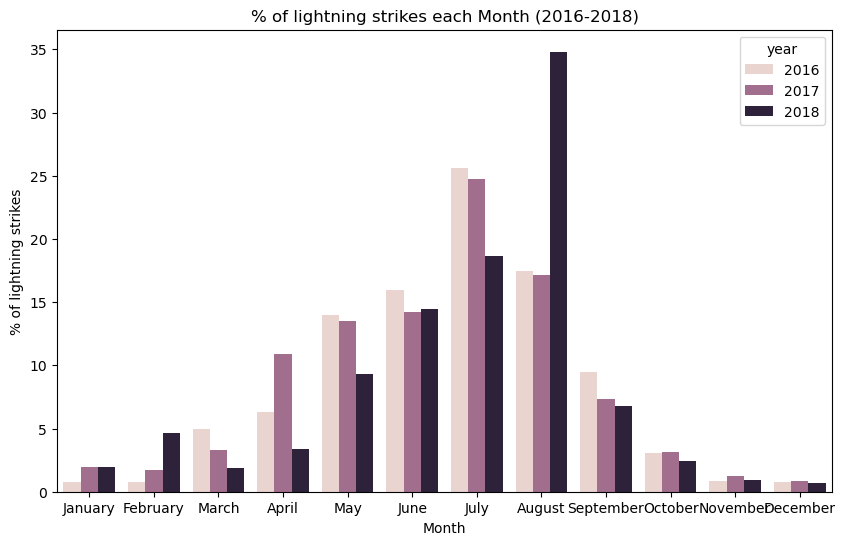

In [25]:
plt.figure(figsize=(10,6));

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

sns.barplot(
    data = percentage_lightning,
    x = 'month_txt',
    y = 'percentage_lightning_per_month',
    hue = 'year',
    order = month_order );
plt.xlabel("Month");
plt.ylabel("% of lightning strikes");
plt.title("% of lightning strikes each Month (2016-2018)");